# Logistic Regression Model for Heart Disease Prediction

## Overview
This notebook builds a complete Logistic Regression model to predict whether a person has heart disease using the Cardiovascular Disease Dataset.

### Target Variable
- **1**: Patient has heart disease
- **0**: Patient does not have heart disease

### Machine Learning Pipeline
1. Data Understanding & Exploration
2. Data Cleaning
3. Exploratory Data Analysis (EDA)
4. Feature Selection
5. Outlier Detection & Handling
6. Data Preprocessing
7. Train-Test Split
8. Model Training
9. Overfitting Check
10. Model Evaluation
11. Model Saving
12. Prediction on New Data

## Section 1: Import Required Libraries

Import all necessary libraries for data processing, visualization, and machine learning model building.


In [2]:
# Data Processing Libraries
import pandas as pd
import numpy as np

# Data Visualization Libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report,
                             ConfusionMatrixDisplay, roc_curve, auc)

# Model Saving Libraries
import pickle
import joblib
import os

# Suppress warnings for cleaner output
import warnings
warnings.filterwarnings('ignore')

# Set visualization style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print(" All required libraries imported successfully!")

 All required libraries imported successfully!


## Section 2: Load and Explore Dataset

Load the CSV file from the folder structure into a pandas DataFrame and perform initial exploration.

In [3]:
# Load the CSV file
csv_path = 'Cardiovascular_Disease_Dataset.csv'

# Check if file exists
if os.path.exists(csv_path):
    df = pd.read_csv(csv_path)
    print(f" Data loaded successfully!")
    print(f"File: {csv_path}\n")
else:
    raise FileNotFoundError(f"CSV file not found at {csv_path}")

# Display dataset shape and basic information
print("=" * 80)
print("DATASET SHAPE AND BASIC INFORMATION")
print("=" * 80)
print(f"Dataset shape: {df.shape}")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}\n")

# Display column names and data types
print("Column Names and Data Types:")
print(df.dtypes)
print("\n")

# Display first 5 rows
print("=" * 80)
print("FIRST 5 ROWS OF THE DATASET")
print("=" * 80)
print(df.head())
print()

# ============================================================================
# REMOVE UNWANTED COLUMNS (IDs and non-predictive features)
# ============================================================================
print("=" * 80)
print("REMOVING UNWANTED COLUMNS")
print("=" * 80)

# Define unwanted columns (IDs, identifiers)
unwanted_col_patterns = ['id', 'ID', 'patient', 'patientid', 'record', 'index']

# Find unwanted columns
columns_to_remove = []
for col in df.columns:
    col_lower = col.lower()
    for pattern in unwanted_col_patterns:
        if pattern in col_lower:
            columns_to_remove.append(col)
            break

if columns_to_remove:
    print(f"\nColumns identified for removal (IDs and identifiers):")
    for col in columns_to_remove:
        print(f"  - {col}")
    
    df.drop(columns=columns_to_remove, inplace=True)
    print(f"\n✓ Removed {len(columns_to_remove)} unwanted columns")
else:
    print("\n✓ No unwanted columns found")

print(f"\nDataset shape after removing unwanted columns: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")
print()

# ============================================================================
# REMOVE UNWANTED COLUMNS (IDs and non-predictive features)
# ============================================================================
print("=" * 80)
print("REMOVING UNWANTED COLUMNS")
print("=" * 80)

# Define unwanted columns (IDs, identifiers)
unwanted_col_patterns = ['id', 'ID', 'patient', 'patientid', 'record', 'index']

# Find unwanted columns
columns_to_remove = []
for col in df.columns:
    col_lower = col.lower()
    for pattern in unwanted_col_patterns:
        if pattern in col_lower:
            columns_to_remove.append(col)
            break

if columns_to_remove:
    print(f"\nColumnsIdentified for removal (IDs and identifiers):")
    for col in columns_to_remove:
        print(f"  - {col}")
    
    df.drop(columns=columns_to_remove, inplace=True)
    print(f"\n✓ Removed {len(columns_to_remove)} unwanted columns")
else:
    print("\n✓ No unwanted columns found")

print(f"\nDataset shape after removing unwanted columns: {df.shape}")
print(f"Remaining columns: {list(df.columns)}")

 Data loaded successfully!
File: Cardiovascular_Disease_Dataset.csv

DATASET SHAPE AND BASIC INFORMATION
Dataset shape: (1000, 14)
Rows: 1000, Columns: 14

Column Names and Data Types:
patientid              int64
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object


FIRST 5 ROWS OF THE DATASET
   patientid  age  gender  chestpain  restingBP  serumcholestrol  \
0     103368   53       1          2        171                0   
1     119250   40       1          0         94              229   
2     119372   49       1          2        133              142   
3     132514   43       1          0        138              295   
4     146211   31       1

In [4]:
# Check for missing values
print("=" * 80)
print("MISSING VALUES ANALYSIS")
print("=" * 80)
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({
    'Column': df.columns,
    'Missing_Count': missing_values.values,
    'Percentage': missing_percentage.values
})
print(missing_df[missing_df['Missing_Count'] > 0])
if missing_df['Missing_Count'].sum() == 0:
    print(" No missing values found in the dataset!")
print("\n")

# Display basic statistics
print("=" * 80)
print("BASIC STATISTICS")
print("=" * 80)
print(df.describe())

MISSING VALUES ANALYSIS
Empty DataFrame
Columns: [Column, Missing_Count, Percentage]
Index: []
 No missing values found in the dataset!


BASIC STATISTICS
              age       gender    chestpain    restingBP  serumcholestrol  \
count  1000.00000  1000.000000  1000.000000  1000.000000      1000.000000   
mean     49.24200     0.765000     0.980000   151.747000       311.447000   
std      17.86473     0.424211     0.953157    29.965228       132.443801   
min      20.00000     0.000000     0.000000    94.000000         0.000000   
25%      34.00000     1.000000     0.000000   129.000000       235.750000   
50%      49.00000     1.000000     1.000000   147.000000       318.000000   
75%      64.25000     1.000000     2.000000   181.000000       404.250000   
max      80.00000     1.000000     3.000000   200.000000       602.000000   

       fastingbloodsugar  restingrelectro  maxheartrate  exerciseangia  \
count        1000.000000      1000.000000   1000.000000    1000.000000   
mea

In [5]:
print("=" * 80)
print("REMOVING UNWANTED COLUMNS (IDs, Identifiers)")
print("=" * 80)

# Check for common unwanted column names that should not be used for prediction
unwanted_patterns = ['id', 'ID', 'patient', 'patientid', 'record', 'index']

# Find columns to remove
columns_to_remove = []
for col in df.columns:
    col_lower = col.lower()
    for pattern in unwanted_patterns:
        if pattern in col_lower:
            columns_to_remove.append(col)
            break

# Remove unwanted columns
if columns_to_remove:
    print(f"\nUnwanted columns found (not useful for prediction):")
    for col in columns_to_remove:
        print(f"   '{col}' - will be removed")
    
    df.drop(columns=columns_to_remove, inplace=True)
    print(f"\n Removed {len(columns_to_remove)} unwanted columns")
else:
    print("\n No unwanted columns (like patientid) found")

print(f"\nDataset shape after cleanup: {df.shape}")
print(f"Useful columns for training: {list(df.columns)}")
print()

REMOVING UNWANTED COLUMNS (IDs, Identifiers)

 No unwanted columns (like patientid) found

Dataset shape after cleanup: (1000, 13)
Useful columns for training: ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels', 'target']



## Section 3: Data Cleaning

Handle missing values, remove duplicates, and verify data consistency.

In [6]:
# Step 1: Handle missing values
print("=" * 80)
print("DATA CLEANING STEPS")
print("=" * 80)

# Check if there are any missing values
if df.isnull().sum().sum() > 0:
    print("Handling missing values...")
    # For numerical columns: fill with median
    numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns
    for col in numerical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    # For categorical columns: fill with mode
    categorical_cols = df.select_dtypes(include=['object']).columns
    for col in categorical_cols:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].mode()[0], inplace=True)
    
    print(f" Missing values handled!")
else:
    print(" No missing values to handle!")

print()

# Step 2: Remove duplicate rows
initial_rows = len(df)
df.drop_duplicates(inplace=True)
removed_duplicates = initial_rows - len(df)

if removed_duplicates > 0:
    print(f" Removed {removed_duplicates} duplicate rows")
else:
    print(f" No duplicate rows found")

print(f"Dataset shape after cleaning: {df.shape}")
print()

# Step 3: Verify data consistency
print("Data Consistency Check:")
print(f"- Total rows: {len(df)}")
print(f"- Total columns: {len(df.columns)}")
print(f"- Data types:")
print(df.dtypes)
print("\n Data cleaning completed!")

DATA CLEANING STEPS
 No missing values to handle!

 No duplicate rows found
Dataset shape after cleaning: (1000, 13)

Data Consistency Check:
- Total rows: 1000
- Total columns: 13
- Data types:
age                    int64
gender                 int64
chestpain              int64
restingBP              int64
serumcholestrol        int64
fastingbloodsugar      int64
restingrelectro        int64
maxheartrate           int64
exerciseangia          int64
oldpeak              float64
slope                  int64
noofmajorvessels       int64
target                 int64
dtype: object

 Data cleaning completed!


## Section 4: Exploratory Data Analysis (EDA)

Visualize feature distributions and analyze relationships with the target variable.

TARGET VARIABLE DISTRIBUTION
Target variable: 'target'

Value counts:
target
1    580
0    420
Name: count, dtype: int64

Value distribution (%):
target
1    58.0
0    42.0
Name: proportion, dtype: float64



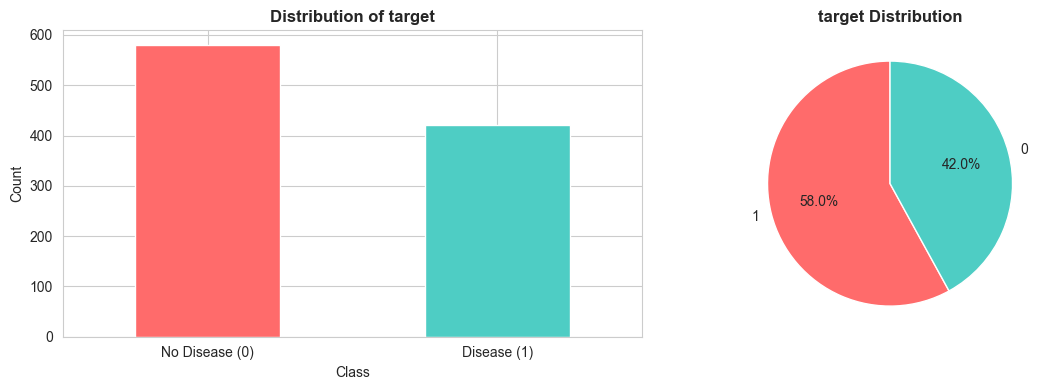

In [7]:
# Check target variable distribution
print("=" * 80)
print("TARGET VARIABLE DISTRIBUTION")
print("=" * 80)

# Identify target column
target_col = 'target' if 'target' in df.columns else df.columns[-1]
print(f"Target variable: '{target_col}'")
print("\nValue counts:")
print(df[target_col].value_counts())
print("\nValue distribution (%):")
print(df[target_col].value_counts(normalize=True) * 100)
print()

# Visualize target distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Bar plot
df[target_col].value_counts().plot(kind='bar', ax=axes[0], color=['#FF6B6B', '#4ECDC4'])
axes[0].set_title(f'Distribution of {target_col}', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['No Disease (0)', 'Disease (1)'], rotation=0)

# Pie chart
df[target_col].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%',
                                    colors=['#FF6B6B', '#4ECDC4'], startangle=90)
axes[1].set_title(f'{target_col} Distribution', fontsize=12, fontweight='bold')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

print()

CORRELATION ANALYSIS

Correlation with target:
target               1.000000
slope                0.797358
chestpain            0.554228
noofmajorvessels     0.489866
restingBP            0.482387
restingrelectro      0.426837
fastingbloodsugar    0.303233
maxheartrate         0.228343
serumcholestrol      0.195340
oldpeak              0.098053
gender               0.015769
age                  0.008356
exerciseangia       -0.039874
Name: target, dtype: float64



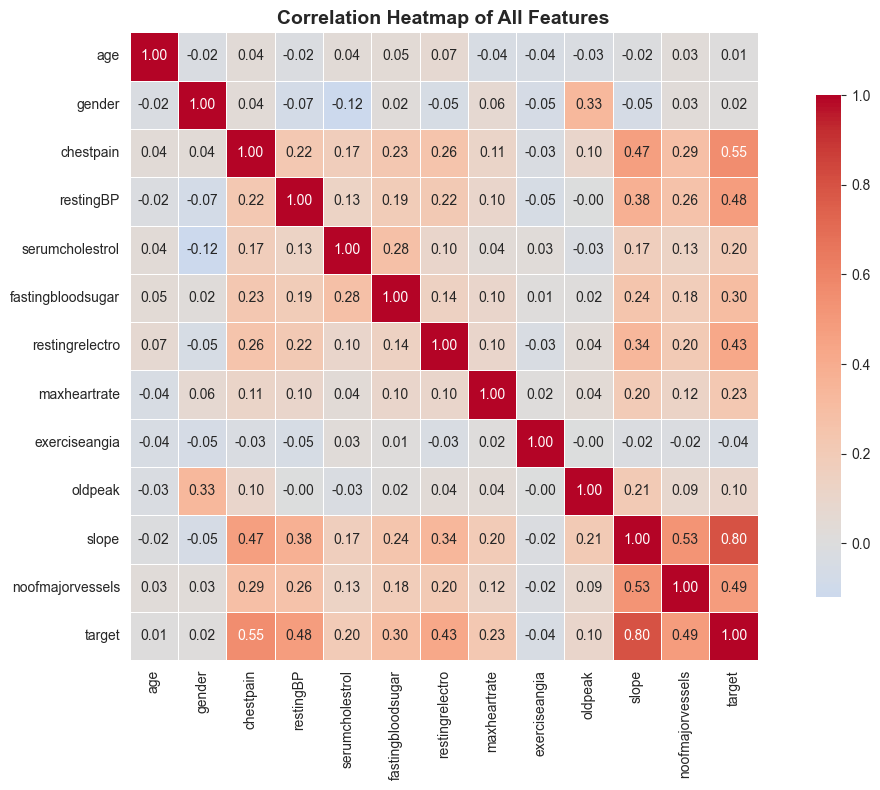

In [8]:
# Correlation analysis
print("=" * 80)
print("CORRELATION ANALYSIS")
print("=" * 80)

# Calculate correlation matrix for numerical columns
correlation_matrix = df.corr(numeric_only=True)

# Display correlation with target variable
print(f"\nCorrelation with {target_col}:")
target_correlation = correlation_matrix[target_col].sort_values(ascending=False)
print(target_correlation)
print()

# Visualize correlation heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title('Correlation Heatmap of All Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print()

FEATURE DISTRIBUTIONS


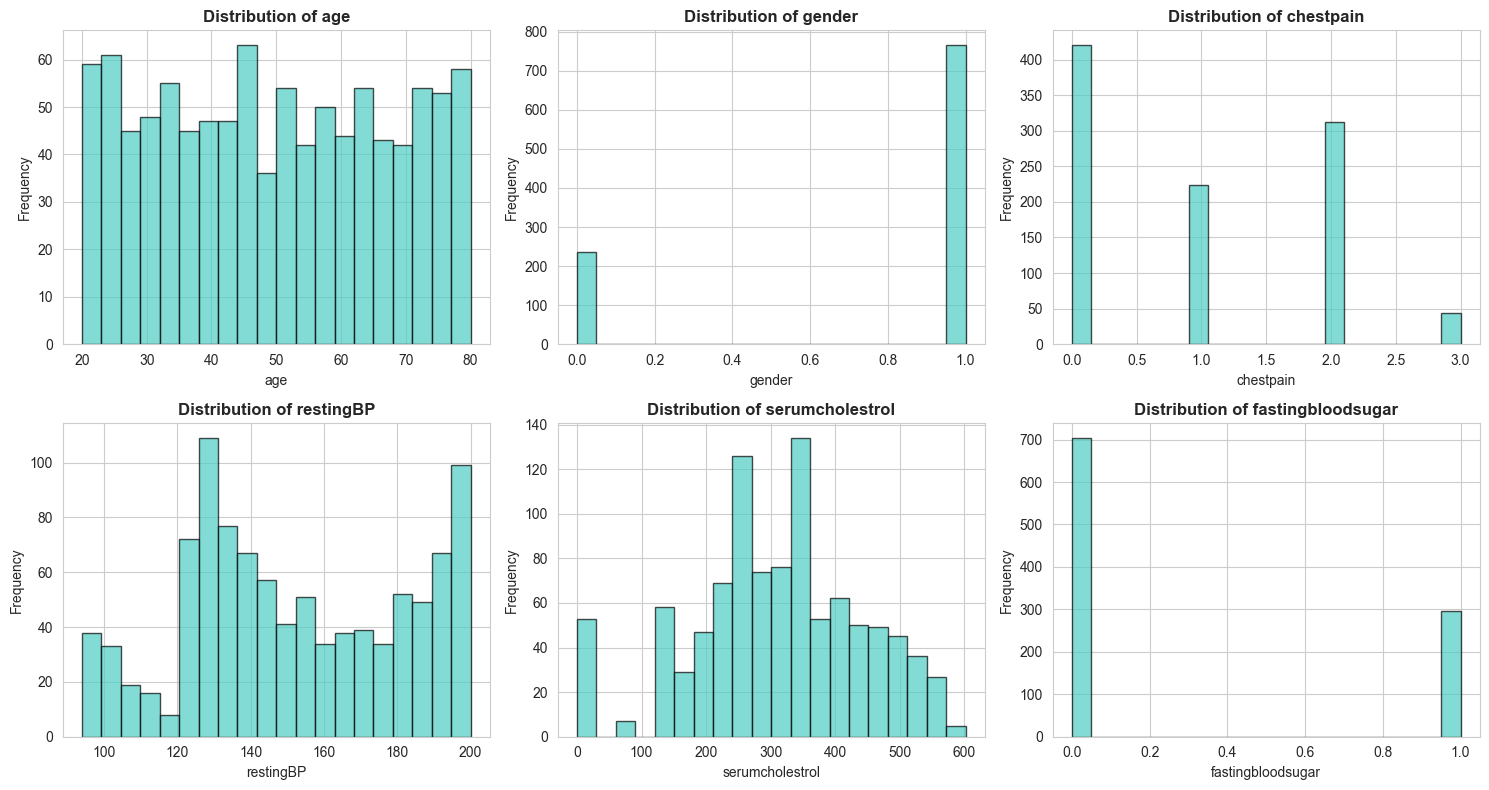

In [9]:
# Feature distributions
print("=" * 80)
print("FEATURE DISTRIBUTIONS")
print("=" * 80)

# Get numerical columns (exclude target)
numerical_columns = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_columns:
    numerical_columns.remove(target_col)

# Plot histograms for key features
num_features_to_plot = min(6, len(numerical_columns))
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_columns[:num_features_to_plot]):
    axes[idx].hist(df[col], bins=20, color='#4ECDC4', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribution of {col}', fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')

# Hide unused subplots
for idx in range(num_features_to_plot, 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print()

## Section 5: Feature Selection

Analyze correlation with target and select relevant features. Drop weakly correlated or irrelevant columns.

In [10]:
print("=" * 80)
print("FEATURE SELECTION - KEEPING ALL FEATURES")
print("=" * 80)

# Analyze correlation with target
target_corr = correlation_matrix[target_col].drop(target_col).abs().sort_values(ascending=False)

print("\nFeatures ranked by correlation with target:")
print(target_corr)
print()

print(" DECISION: Keep all available features for training model")
print("   age - will be included")
print("   gender - will be included")
print("   chestpain - will be included")
print("   restingBP - will be included")
print("   serumcholestrol - will be included")
print("   fastingbloodsugar - will be included")
print("   restingrelectro - will be included")
print("   maxheartrate - will be included")
print("   exerciseangia - will be included")
print("   oldpeak - will be included")
print("   slope - will be included")
print("   noofmajorvessels - will be included")
print()

print("Why keep all features?")
print("   Include all patient information for comprehensive analysis")
print("   Age and gender are important demographic factors")
print("   Model can learn from all features simultaneously")
print("   Better patient profiling and prediction")
print()

# Keep all features (no feature dropping)
df_selected = df.copy()

print(f" All features retained for training")
print(f"Dataset shape after feature selection: {df_selected.shape}")
print(f"Total features: {len(df_selected.columns) - 1}  (excluding target)")  # -1 for target column

FEATURE SELECTION - KEEPING ALL FEATURES

Features ranked by correlation with target:
slope                0.797358
chestpain            0.554228
noofmajorvessels     0.489866
restingBP            0.482387
restingrelectro      0.426837
fastingbloodsugar    0.303233
maxheartrate         0.228343
serumcholestrol      0.195340
oldpeak              0.098053
exerciseangia        0.039874
gender               0.015769
age                  0.008356
Name: target, dtype: float64

 DECISION: Keep all available features for training model
   age - will be included
   gender - will be included
   chestpain - will be included
   restingBP - will be included
   serumcholestrol - will be included
   fastingbloodsugar - will be included
   restingrelectro - will be included
   maxheartrate - will be included
   exerciseangia - will be included
   oldpeak - will be included
   slope - will be included
   noofmajorvessels - will be included

Why keep all features?
   Include all patient information for 

## Section 6: Outlier Detection and Handling

Use IQR method and boxplots to detect and handle outliers.

OUTLIER DETECTION AND HANDLING (IQR METHOD)

Boxplots BEFORE outlier handling:


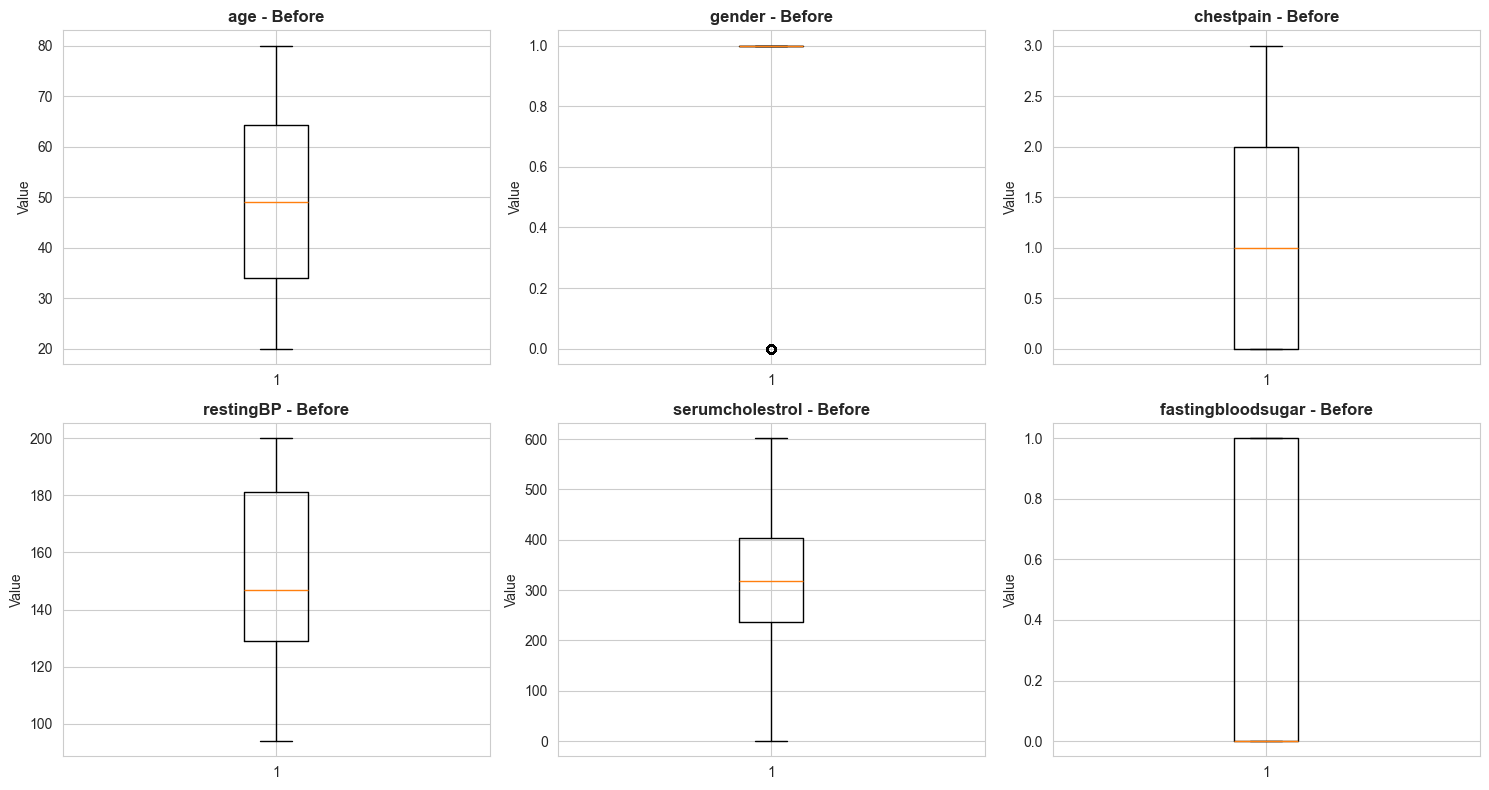

Total outliers detected: 235

Outlier Summary:
  Feature  Outlier_Count  Lower_Bound  Upper_Bound
0  gender            235          1.0          1.0


In [11]:
print("=" * 80)
print("OUTLIER DETECTION AND HANDLING (IQR METHOD)")
print("=" * 80)

# Prepare a copy for outlier handling
df_processed = df_selected.copy()

# Get numerical columns (exclude target)
numerical_cols_for_outliers = df_processed.select_dtypes(include=['int64', 'float64']).columns.tolist()
if target_col in numerical_cols_for_outliers:
    numerical_cols_for_outliers.remove(target_col)

# Track outliers
total_outliers_before = 0
outlier_summary = []

# Detect outliers using IQR method
for col in numerical_cols_for_outliers:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Count outliers
    outliers_mask = (df_processed[col] < lower_bound) | (df_processed[col] > upper_bound)
    outlier_count = outliers_mask.sum()
    
    if outlier_count > 0:
        total_outliers_before += outlier_count
        outlier_summary.append({
            'Feature': col,
            'Outlier_Count': outlier_count,
            'Lower_Bound': lower_bound,
            'Upper_Bound': upper_bound
        })

# Visualize boxplots before outlier handling
print("\nBoxplots BEFORE outlier handling:")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols_for_outliers[:6]):
    axes[idx].boxplot(df_processed[col], vert=True)
    axes[idx].set_title(f'{col} - Before', fontweight='bold')
    axes[idx].set_ylabel('Value')

for idx in range(len(numerical_cols_for_outliers[:6]), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print(f"Total outliers detected: {total_outliers_before}")
if outlier_summary:
    print("\nOutlier Summary:")
    print(pd.DataFrame(outlier_summary))
else:
    print(" No outliers detected!")


HANDLING OUTLIERS (CAPPING METHOD)
 Outliers capped using IQR bounds
(Values below lower bound capped to lower bound, and above upper bound capped to upper bound)

Boxplots AFTER outlier handling:


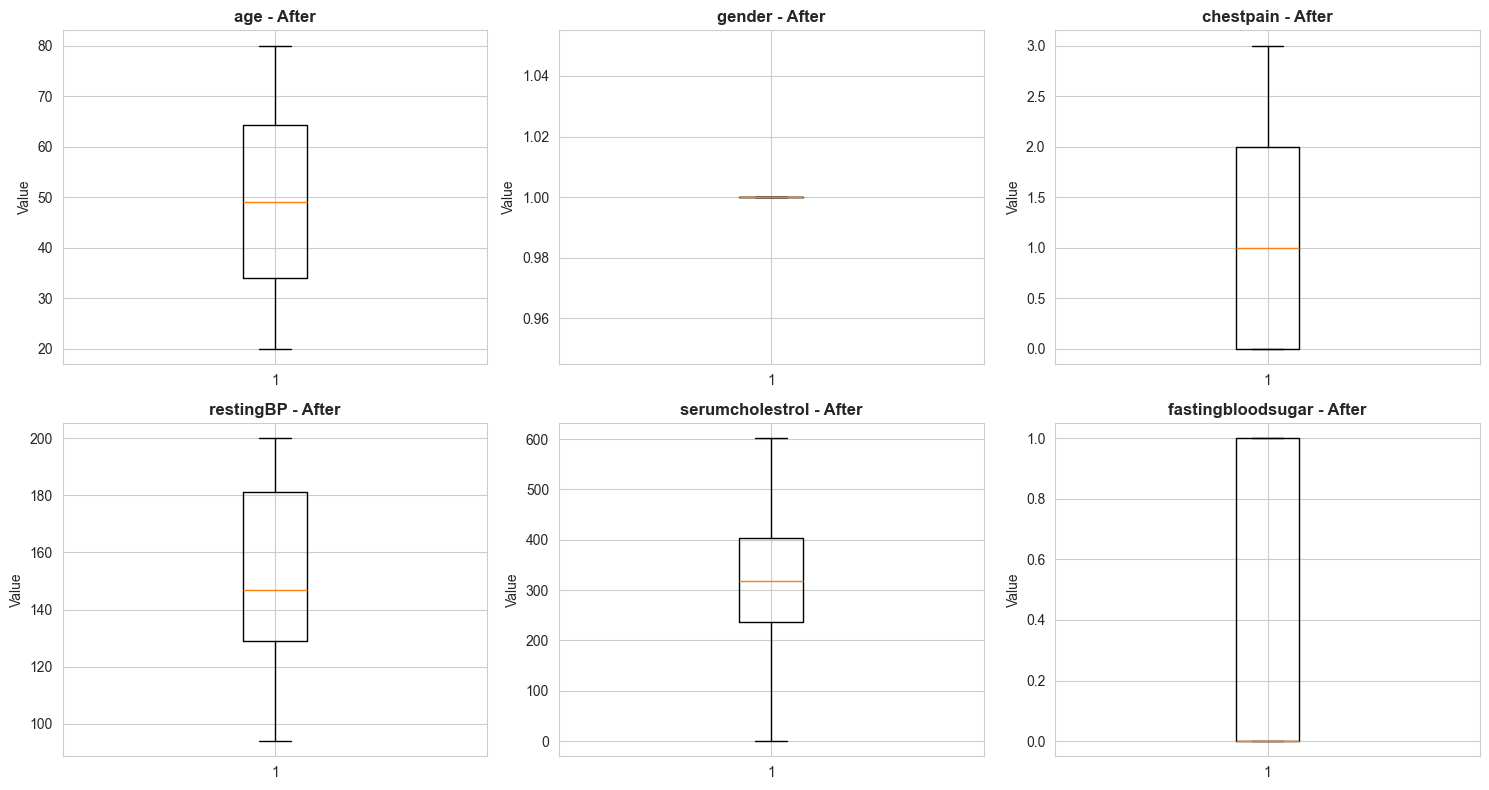


 Outlier handling completed!


In [12]:
# Handle outliers by capping (winsorization)
print("\n" + "=" * 80)
print("HANDLING OUTLIERS (CAPPING METHOD)")
print("=" * 80)

for col in numerical_cols_for_outliers:
    Q1 = df_processed[col].quantile(0.25)
    Q3 = df_processed[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap outliers instead of removing them
    df_processed[col] = df_processed[col].clip(lower=lower_bound, upper=upper_bound)

print(" Outliers capped using IQR bounds")
print("(Values below lower bound capped to lower bound, and above upper bound capped to upper bound)")
print()

# Visualize boxplots after outlier handling
print("Boxplots AFTER outlier handling:")
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for idx, col in enumerate(numerical_cols_for_outliers[:6]):
    axes[idx].boxplot(df_processed[col], vert=True)
    axes[idx].set_title(f'{col} - After', fontweight='bold')
    axes[idx].set_ylabel('Value')

for idx in range(len(numerical_cols_for_outliers[:6]), 6):
    axes[idx].axis('off')

plt.tight_layout()
plt.show()

print("\n Outlier handling completed!")

## Section 7: Data Preprocessing

Encode categorical variables and standardize numerical features using StandardScaler.

In [13]:
print("=" * 80)
print("DATA PREPROCESSING")
print("=" * 80)

# Separate features and target
X = df_processed.drop(columns=[target_col])
y = df_processed[target_col]

# Get categorical and numerical columns
categorical_cols = X.select_dtypes(include=['object']).columns.tolist()
numerical_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

print(f"Categorical columns: {categorical_cols if categorical_cols else 'None'}")
print(f"Numerical columns: {numerical_cols}")
print()

# Step 1: Encode categorical variables
print("Step 1: Encoding Categorical Variables")
print("-" * 40)

if categorical_cols:
    print(f"Encoding {len(categorical_cols)} categorical columns using Label Encoding...")
    
    from sklearn.preprocessing import LabelEncoder
    
    label_encoders = {}
    for col in categorical_cols:
        le = LabelEncoder()
        X[col] = le.fit_transform(X[col].astype(str))
        label_encoders[col] = le
        print(f"   Encoded '{col}'")
else:
    print(" No categorical columns to encode")

print()

# Step 2: Standardize numerical features
print("Step 2: Standardizing Numerical Features")
print("-" * 40)

print(f"Standardizing {len(numerical_cols)} numerical features using StandardScaler")

# Initialize StandardScaler
scaler = StandardScaler()

# Fit and transform numerical features
X[numerical_cols] = scaler.fit_transform(X[numerical_cols])

print(f" StandardScaler fitted and applied")
print(f"  - Mean of scaled features: {X[numerical_cols].mean().mean():.6f}")
print(f"  - Std of scaled features: {X[numerical_cols].std().mean():.6f}")

print("\n" + "=" * 80)
print("PREPROCESSED DATA SUMMARY")
print("=" * 80)
print(f"Features shape: {X.shape}")
print(f"Target shape: {y.shape}")
print(f"\nPreprocessed features (first 5 rows):")
print(X.head())

DATA PREPROCESSING
Categorical columns: None
Numerical columns: ['age', 'gender', 'chestpain', 'restingBP', 'serumcholestrol', 'fastingbloodsugar', 'restingrelectro', 'maxheartrate', 'exerciseangia', 'oldpeak', 'slope', 'noofmajorvessels']

Step 1: Encoding Categorical Variables
----------------------------------------
 No categorical columns to encode

Step 2: Standardizing Numerical Features
----------------------------------------
Standardizing 12 numerical features using StandardScaler
 StandardScaler fitted and applied
  - Mean of scaled features: -0.000000
  - Std of scaled features: 0.917125

PREPROCESSED DATA SUMMARY
Features shape: (1000, 12)
Target shape: (1000,)

Preprocessed features (first 5 rows):
        age  gender  chestpain  restingBP  serumcholestrol  fastingbloodsugar  \
0  0.210464     0.0   1.070663   0.642833        -2.352717          -0.648425   
1 -0.517591     0.0  -1.028677  -1.928098        -0.622817          -0.648425   
2 -0.013553     0.0   1.070663  -0.6

## Section 8: Train-Test Split

Split dataset into training (80%) and testing (20%) sets for model evaluation.

In [14]:
print("=" * 80)
print("TRAIN-TEST SPLIT")
print("=" * 80)

# Split data into training (80%) and testing (20%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]} ({100 * 0.8:.0f}%)")
print(f"Testing set size: {X_test.shape[0]} ({100 * 0.2:.0f}%)")
print(f"Total samples: {len(X)}")
print()

print("Training set class distribution:")
print(y_train.value_counts())
print(f"Percentage: {y_train.value_counts(normalize=True) * 100}")
print()

print("Testing set class distribution:")
print(y_test.value_counts())
print(f"Percentage: {y_test.value_counts(normalize=True) * 100}")

print("\n Train-test split completed (stratified, random_state=42)")

TRAIN-TEST SPLIT
Training set size: 800 (80%)
Testing set size: 200 (20%)
Total samples: 1000

Training set class distribution:
target
1    464
0    336
Name: count, dtype: int64
Percentage: target
1    58.0
0    42.0
Name: proportion, dtype: float64

Testing set class distribution:
target
1    116
0     84
Name: count, dtype: int64
Percentage: target
1    58.0
0    42.0
Name: proportion, dtype: float64

 Train-test split completed (stratified, random_state=42)


## Section 9: Model Training

Initialize and train the Logistic Regression model.

MODEL TRAINING - LOGISTIC REGRESSION
Initializing Logistic Regression model...
Model: LogisticRegression
Parameters:
  - random_state: 42 (for reproducibility)
  - max_iter: 1000 (maximum iterations for convergence)
  - solver: lbfgs (optimization algorithm)

Training the model on training data...
 Model training completed!

Model Coefficients (Feature Importance):
----------------------------------------
          Feature  Coefficient  Abs_Coefficient
            slope     4.160942         4.160942
        chestpain     0.989125         0.989125
        restingBP     0.790964         0.790964
          oldpeak    -0.757073         0.757073
  restingrelectro     0.732069         0.732069
fastingbloodsugar     0.420554         0.420554
     maxheartrate     0.408469         0.408469
 noofmajorvessels     0.199412         0.199412
              age    -0.139042         0.139042
  serumcholestrol    -0.138329         0.138329
    exerciseangia    -0.000121         0.000121
           gend

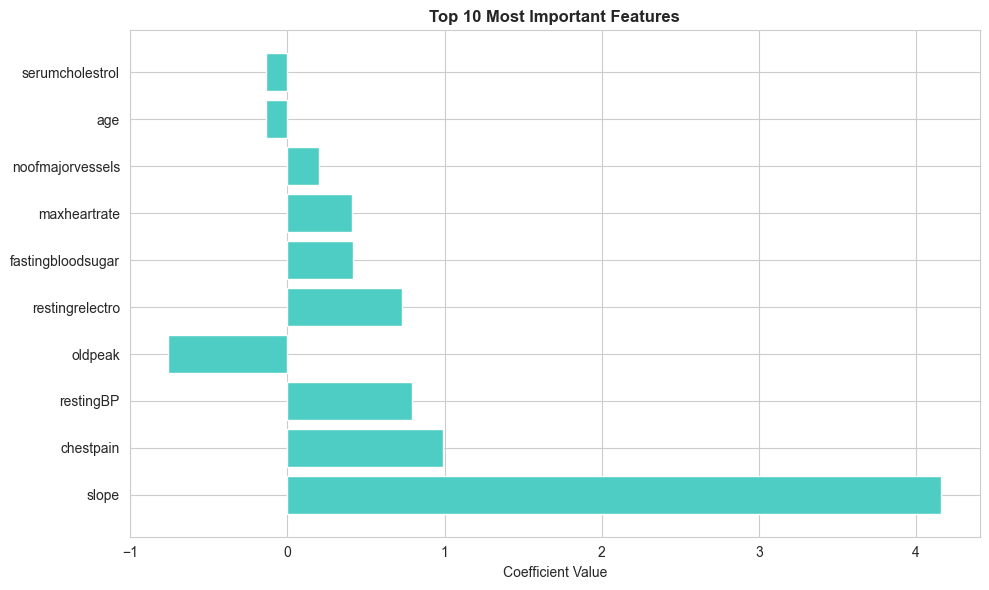

In [15]:
print("=" * 80)
print("MODEL TRAINING - LOGISTIC REGRESSION")
print("=" * 80)

# Initialize Logistic Regression model
print("Initializing Logistic Regression model...")
log_reg = LogisticRegression(
    random_state=42,
    max_iter=1000,
    solver='lbfgs',
    verbose=0
)

print(f"Model: {type(log_reg).__name__}")
print(f"Parameters:")
print(f"  - random_state: 42 (for reproducibility)")
print(f"  - max_iter: 1000 (maximum iterations for convergence)")
print(f"  - solver: lbfgs (optimization algorithm)")
print()

# Train the model
print("Training the model on training data...")
log_reg.fit(X_train, y_train)

print(" Model training completed!")
print()

# Display model coefficients
print("Model Coefficients (Feature Importance):")
print("-" * 40)

# Get feature importance
feature_importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})
feature_importance['Abs_Coefficient'] = abs(feature_importance['Coefficient'])
feature_importance = feature_importance.sort_values('Abs_Coefficient', ascending=False)

print(feature_importance.to_string(index=False))
print()

print(f"Model Intercept: {log_reg.intercept_[0]:.6f}")
print()

# Visualize top 10 features by importance
top_features = feature_importance.head(10)
plt.figure(figsize=(10, 6))
plt.barh(range(len(top_features)), top_features['Coefficient'].values, color='#4ECDC4')
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Coefficient Value')
plt.title('Top 10 Most Important Features', fontweight='bold', fontsize=12)
plt.tight_layout()
plt.show()

## Section 10: Overfitting Check

Compare training vs testing accuracy to detect overfitting or underfitting.

OVERFITTING CHECK
Training Accuracy: 0.9563 (95.62%)
Testing Accuracy: 0.9700 (97.00%)
Accuracy Difference: -0.0137

Model Performance Analysis:
----------------------------------------
 GOOD FIT:
   - Training and testing accuracies are close
   - Model generalizes well to unseen data



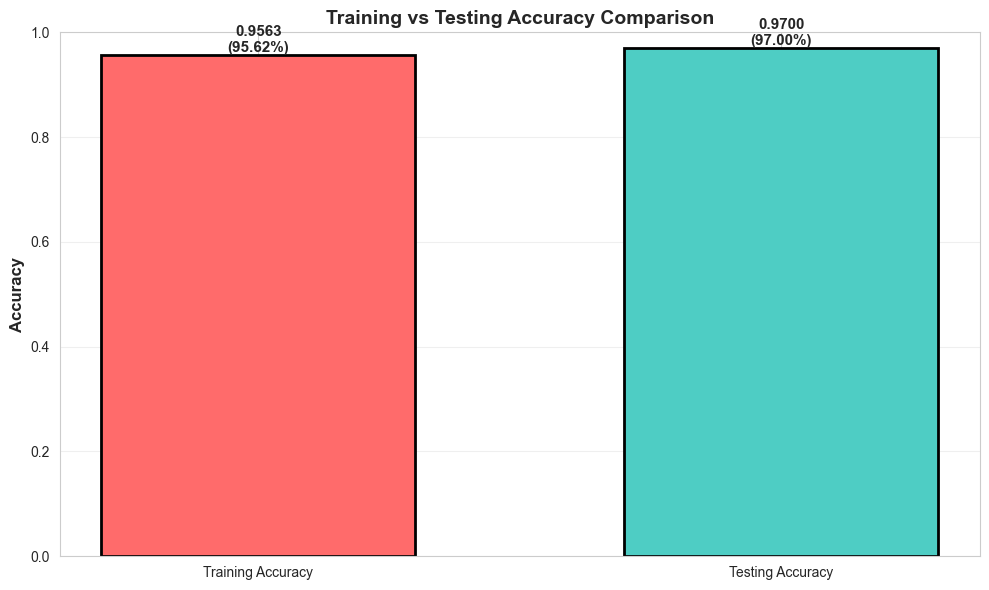

In [16]:
print("=" * 80)
print("OVERFITTING CHECK")
print("=" * 80)

# Calculate training accuracy
y_train_pred = log_reg.predict(X_train)
train_accuracy = accuracy_score(y_train, y_train_pred)

# Calculate testing accuracy
y_test_pred = log_reg.predict(X_test)
test_accuracy = accuracy_score(y_test, y_test_pred)

# Calculate the difference
accuracy_diff = train_accuracy - test_accuracy

print(f"Training Accuracy: {train_accuracy:.4f} ({train_accuracy * 100:.2f}%)")
print(f"Testing Accuracy: {test_accuracy:.4f} ({test_accuracy * 100:.2f}%)")
print(f"Accuracy Difference: {accuracy_diff:.4f}")
print()

# Analyze overfitting/underfitting
print("Model Performance Analysis:")
print("-" * 40)

if accuracy_diff > 0.05:
    if test_accuracy < 0.70:
        print("  UNDERFITTING DETECTED:")
        print("   - Training accuracy is significantly higher than testing accuracy")
        print("   - Both accuracies are relatively low")
        print("   - Model is not capturing the underlying patterns well")
        print("   - Consider: more features, more complex model, or more data")
    else:
        print("  OVERFITTING DETECTED:")
        print("   - Training accuracy is significantly higher than testing accuracy")
        print("   - Consider: regularization, cross-validation, or more data")
else:
    if test_accuracy > 0.90:
        print(" GOOD FIT:")
        print("   - Training and testing accuracies are close")
        print("   - Model generalizes well to unseen data")
    elif test_accuracy > 0.70:
        print(" REASONABLE FIT:")
        print("   - Training and testing accuracies are similar")
        print("   - Model shows decent generalization")
    else:
        print("  UNDERFITTING DETECTED:")
        print("   - Both training and testing accuracies are low")
        print("   - Consider: more features or more complex model")

print()

# Visualize comparison
fig, ax = plt.subplots(1, 1, figsize=(10, 6))

accuracies = [train_accuracy, test_accuracy]
labels = ['Training Accuracy', 'Testing Accuracy']
colors = ['#FF6B6B', '#4ECDC4']

bars = ax.bar(labels, accuracies, color=colors, width=0.6, edgecolor='black', linewidth=2)

# Add value labels on bars
for bar in bars:
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}\n({height*100:.2f}%)',
            ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_ylim([0, 1.0])
ax.set_ylabel('Accuracy', fontsize=12, fontweight='bold')
ax.set_title('Training vs Testing Accuracy Comparison', fontsize=14, fontweight='bold')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


## Section 11: Comprehensive Model Evaluation

Evaluate model performance using multiple metrics: accuracy, confusion matrix, and classification report.

COMPREHENSIVE MODEL EVALUATION

1. ACCURACY SCORE
----------------------------------------
Test Accuracy: 0.9700 (97.00%)
(Percentage of correctly classified samples)

2. CONFUSION MATRIX
----------------------------------------
[[ 81   3]
 [  3 113]]

True Negatives (TN): 81
False Positives (FP): 3
False Negatives (FN): 3
True Positives (TP): 113

3. CLASSIFICATION REPORT
----------------------------------------
                precision    recall  f1-score   support

No Disease (0)       0.96      0.96      0.96        84
   Disease (1)       0.97      0.97      0.97       116

      accuracy                           0.97       200
     macro avg       0.97      0.97      0.97       200
  weighted avg       0.97      0.97      0.97       200


4. ADDITIONAL METRICS
----------------------------------------
Sensitivity (True Positive Rate / Recall): 0.9741
  (Proportion of actual disease cases correctly identified)
Specificity (True Negative Rate): 0.9643
  (Proportion of no-disease c

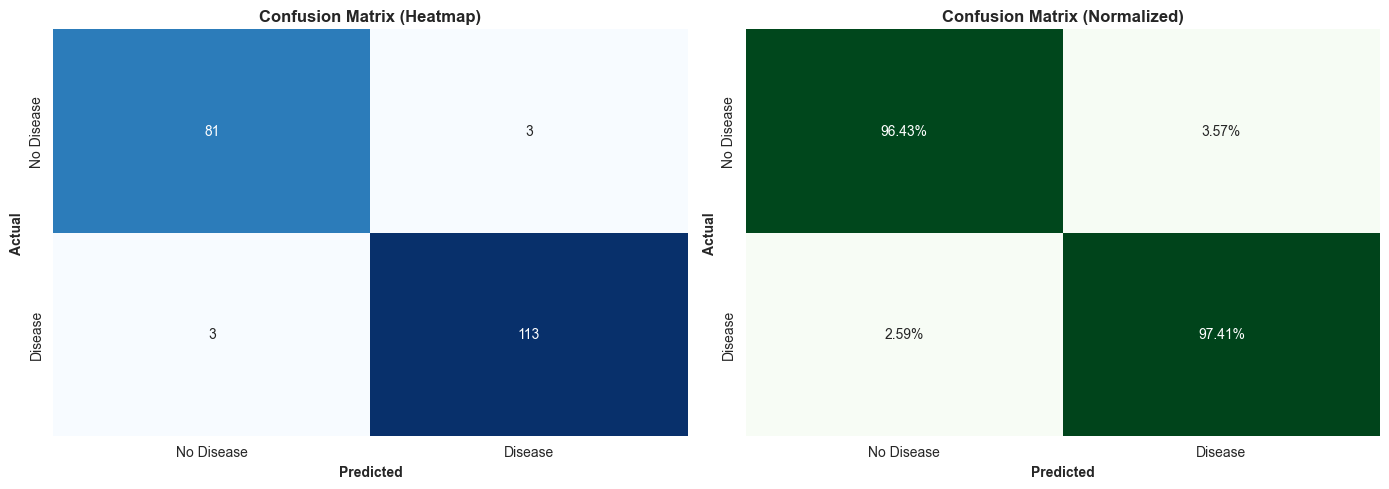


 Model evaluation completed!


In [17]:
print("=" * 80)
print("COMPREHENSIVE MODEL EVALUATION")
print("=" * 80)
print()

# Make predictions on test set
y_test_pred_proba = log_reg.predict_proba(X_test)[:, 1]

# 1. Accuracy Score
print("1. ACCURACY SCORE")
print("-" * 40)
accuracy = accuracy_score(y_test, y_test_pred)
print(f"Test Accuracy: {accuracy:.4f} ({accuracy * 100:.2f}%)")
print("(Percentage of correctly classified samples)")
print()

# 2. Confusion Matrix
print("2. CONFUSION MATRIX")
print("-" * 40)
cm = confusion_matrix(y_test, y_test_pred)
print(cm)
print()

# Interpret confusion matrix
tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")
print()

# 3. Classification Report
print("3. CLASSIFICATION REPORT")
print("-" * 40)
print(classification_report(y_test, y_test_pred, target_names=['No Disease (0)', 'Disease (1)']))
print()

# 4. Additional Metrics
print("4. ADDITIONAL METRICS")
print("-" * 40)

# Sensitivity (Recall): TP / (TP + FN)
sensitivity = tp / (tp + fn)
print(f"Sensitivity (True Positive Rate / Recall): {sensitivity:.4f}")
print("  (Proportion of actual disease cases correctly identified)")

# Specificity: TN / (TN + FP)
specificity = tn / (tn + fp)
print(f"Specificity (True Negative Rate): {specificity:.4f}")
print("  (Proportion of no-disease cases correctly identified)")

# Precision: TP / (TP + FP)
precision = tp / (tp + fp)
print(f"Precision: {precision:.4f}")
print("  (Of predicted disease cases, proportion that are correct)")

# F1-Score
f1 = 2 * (precision * sensitivity) / (precision + sensitivity)
print(f"F1-Score: {f1:.4f}")
print("  (Harmonic mean of precision and recall)")

print()

# Visualize Confusion Matrix
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=axes[0],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[0].set_xlabel('Predicted', fontweight='bold')
axes[0].set_ylabel('Actual', fontweight='bold')
axes[0].set_title('Confusion Matrix (Heatmap)', fontweight='bold', fontsize=12)

# Normalized Confusion Matrix
cm_normalized = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
sns.heatmap(cm_normalized, annot=True, fmt='.2%', cmap='Greens', cbar=False, ax=axes[1],
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
axes[1].set_xlabel('Predicted', fontweight='bold')
axes[1].set_ylabel('Actual', fontweight='bold')
axes[1].set_title('Confusion Matrix (Normalized)', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.show()

print("\n Model evaluation completed!")